<a href="https://colab.research.google.com/github/onolf/aprendizaje_automatico_final/blob/main/7_Odilón_Nolf_proyecto_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Datos del Estudiante**

Nombre: Odilón Nolf Sánchez

CI: 4189076

# **Desafío de aprendizaje supervisado**

**Primera etapa**

0. Con ayuda del profesor seleccione un grupo conformado por tres compañeros
1. Consulte el problema presentado en la siguiente sección
2. Consulte a una LLM IA cuales son las etapas más fundamentales de un proyecto de aprendizaje automático
3. Implemente un proyecto en Colab de uno de los dos problemas propuestos

**Segunda etapa**

Luego de presentar los resultados de los distintos equipos conformados los compañeros votarán para seleccionar el mejor proyecto.





# **Problema:**

A continuación, exploraremos el dataset de [melanoma](https://drive.google.com/drive/folders/1qqimwfGxePZvxJvly23H81PO5V_330vi?usp=sharing). Los datos consisten en mediciones realizadas a pacientes tras la cirugía para extirpar el cáncer de piel tipo melanoma en el Hospital Universitario de Odense, Dinamarca, entre 1962 y 1977.

El melanoma maligno es un cáncer agresivo y altamente invasivo, lo que dificulta su tratamiento.

Para determinar el grado de avance, la estadificación se basa en la profundidad del tumor. Los puntos de corte actuales de la clasificación TNM son:

- T1:  ≤  1,0 mm de profundidad
- T2: 1,1 a 2,0 mm de profundidad
- T3: 2,1 a 4,0 mm de profundidad
- T4: > 4,0 mm de profundidad

Esto será importante en nuestro análisis ya que crearemos una nueva variable basada en esto.

Utilizando algún algoritmo de clasificación binaria, evalué la capacidad del modelo para anticipar el riesgo de la mortalidad por melanoma a los 5 años (mort_5yr). Esta se definirá, a los 5 años de la cirugía, para determinar quiénes fallecieron por melanoma y quiénes no.
  

Datos:

https://drive.google.com/drive/folders/1qqimwfGxePZvxJvly23H81PO5V_330vi?usp=sharing

Ver:

- https://argoshare.is.ed.ac.uk/healthyr_book/chap09-h1.html  

- https://argoshare.is.ed.ac.uk/healthyr_book/data-preparation-and-exploratory-analysis.html



## 1. Selección y carga de datos

In [34]:
!pip install -q numpy pandas matplotlib seaborn scikit-learn

In [35]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', context='notebook')

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

RND = 42
np.random.seed(RND)
print("Librerías cargadas correctamente.")
print(f"RND = {RND}")

Librerías cargadas correctamente.
RND = 42


In [36]:
# ── Carga ────────────────────────────────────────────────────────────────────
# df = pd.read_csv('datos_desafio/melanoma.csv')
url = 'https://raw.githubusercontent.com/onolf/aprendizaje_automatico_final/refs/heads/main/datos_desafio/melanoma.csv'
df = pd.read_csv(url)
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
print(df.head(3))

# ── Descarte de columnas ─────────────────────────────────────────────────────
# Se eliminan columnas leaky (time, status, status.factor) ya que se derivan
# directamente de la variable objetivo mort_5yr, y columnas redundantes.
cols_drop = ['time', 'status', 'status.factor',   # leaky
             'sex.factor', 'ulcer.factor',          # redundantes con numéricas
             't_stage.factor']                      # redundante con thickness
df = df.drop(columns=cols_drop)

# ── Target ───────────────────────────────────────────────────────────────────
y = (df.pop('mort_5yr') == 'Yes').astype(int)
X = df

print(f"\nFeatures: {X.columns.tolist()}")
print(f"Distribución del target — mort_5yr:")
print(f"  No (0): {(y==0).sum()}  ({(y==0).mean()*100:.1f}%)")
print(f"  Yes (1): {(y==1).sum()}  ({(y==1).mean()*100:.1f}%)")

# ── Split 80/20 con stratify ─────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RND, stratify=y
)
print(f"\nSplit 80/20 (stratify=y):")
print(f"  Entrenamiento : {X_train.shape[0]} muestras")
print(f"  Test          : {X_test.shape[0]} muestras")

Dataset cargado: 205 filas, 12 columnas
   time  status  sex  age  year  thickness  ulcer sex.factor ulcer.factor  \
0    10       3    1   76  1972       6.76      1       Male      Present   
1    30       3    1   56  1968       0.65      0       Male       Absent   
2    35       2    1   41  1977       1.34      0       Male       Absent   

  status.factor t_stage.factor mort_5yr  
0  Died - other             T4       No  
1  Died - other             T1       No  
2         Alive             T2       No  

Features: ['sex', 'age', 'year', 'thickness', 'ulcer']
Distribución del target — mort_5yr:
  No (0): 160  (78.0%)
  Yes (1): 45  (22.0%)

Split 80/20 (stratify=y):
  Entrenamiento : 164 muestras
  Test          : 41 muestras


## 1.5. Análisis exploratorio de datos (EDA)

=== Estadísticas descriptivas ===
          sex     age     year  thickness   ulcer
count  205.00  205.00   205.00     205.00  205.00
mean     0.39   52.46  1969.91       2.92    0.44
std      0.49   16.67     2.58       2.96    0.50
min      0.00    4.00  1962.00       0.10    0.00
25%      0.00   42.00  1968.00       0.97    0.00
50%      0.00   54.00  1970.00       1.94    0.00
75%      1.00   65.00  1972.00       3.56    1.00
max      1.00   95.00  1977.00      17.42    1.00


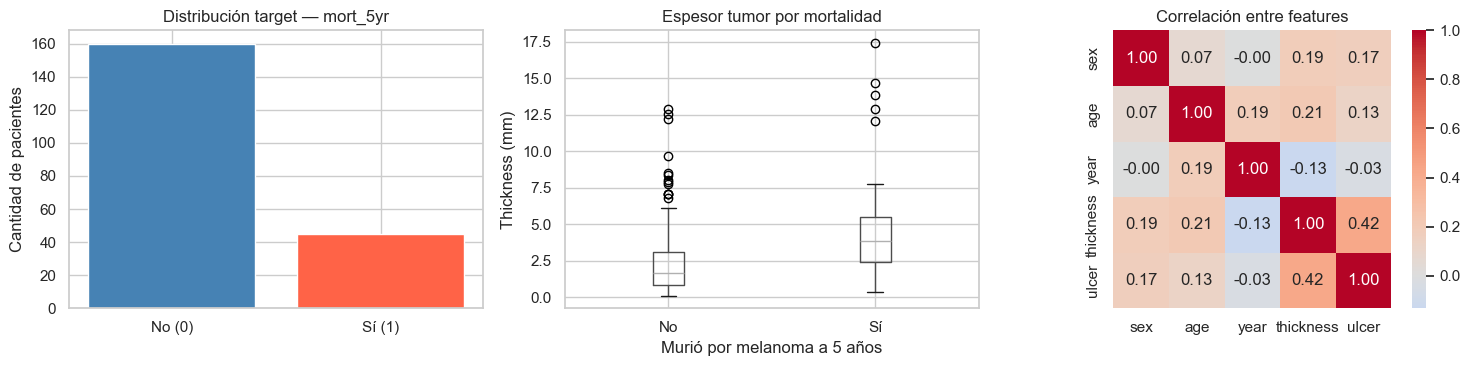

In [37]:
print("=== Estadísticas descriptivas ===")
print(X.describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribución del target
y_counts = pd.Series(y).map({0: 'No (0)', 1: 'Sí (1)'}).value_counts()
axes[0].bar(y_counts.index, y_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Distribución target — mort_5yr')
axes[0].set_ylabel('Cantidad de pacientes')

# Boxplot: thickness por clase
df_plot = X.copy()
df_plot['mort_5yr'] = y.map({0: 'No', 1: 'Sí'})
df_plot.boxplot(column='thickness', by='mort_5yr', ax=axes[1])
axes[1].set_xlabel('Murió por melanoma a 5 años')
axes[1].set_ylabel('Thickness (mm)')
plt.sca(axes[1])
plt.title('Espesor tumor por mortalidad')

# Correlación entre features
corr = X.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[2], square=True)
axes[2].set_title('Correlación entre features')

plt.suptitle('')
plt.tight_layout()
plt.show()

## 2. Construcción de pipelines con escalado

In [38]:
# ── Pipeline 1: StandardScaler + LogisticRegression ─────────────────────────
#
# ¿Por qué usar Pipeline previene el Data Leakage?
# Si aplicamos StandardScaler ANTES de la validación cruzada, el scaler se
# ajusta sobre TODO el dataset (incluyendo los folds de test). Eso significa
# que la media y desviación estándar usadas para escalar incorporan información
# de los datos de evaluación → el modelo "ve" el test antes de tiempo, y los
# scores de CV son artificialmente optimistas (Data Leakage).
#
# Con Pipeline, el scaler se ajusta SOLO sobre los datos de entrenamiento de
# cada fold, y se aplica (sin reajustar) sobre el fold de test. Así se
# garantiza que ninguna información del test "contamina" el preprocesado.
#
pipe_lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=10_000, random_state=RND)
)

# ── Pipeline 2: StandardScaler + RandomForestClassifier ─────────────────────
#
# RandomForest es invariante a la escala (usa umbrales en árboles, no
# distancias), pero incluimos el scaler por consistencia metodológica y porque
# el Pipeline sigue previniendo leakage en cualquier transformación futura.
#
pipe_rf = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=RND, n_jobs=-1)
)

print("Pipeline 1 — Logistic Regression:")
print(pipe_lr)
print()
print("Pipeline 2 — Random Forest:")
print(pipe_rf)

Pipeline 1 — Logistic Regression:
Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(max_iter=10000, random_state=42))])

Pipeline 2 — Random Forest:
Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestclassifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])


## 3. Búsqueda de hiperparámetros con GridSearchCV (cv=5)

In [39]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)

# ── Grid para Logistic Regression ────────────────────────────────────────────
# Los nombres de parámetros usan el formato: <nombre_paso>__<parámetro>
# make_pipeline genera el nombre del paso en minúsculas desde el nombre de clase.
# GridSearchCV evalúa cada combinación con CV estratificada → el StandardScaler
# se reajusta en cada fold interno igual que antes, sin leakage.
param_grid_lr = {
    'logisticregression__C':      [0.01, 0.1, 1.0, 10.0, 100.0],
    'logisticregression__solver': ['lbfgs', 'liblinear'],
}
grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=cv,
                       scoring='roc_auc', n_jobs=-1,
                       return_train_score=True)
grid_lr.fit(X_train, y_train)

print("Logistic Regression — GridSearchCV (cv=5, scoring=roc_auc):")
print(f"  Mejor C       : {grid_lr.best_params_['logisticregression__C']}")
print(f"  Mejor solver  : {grid_lr.best_params_['logisticregression__solver']}")
print(f"  Mejor ROC-AUC : {grid_lr.best_score_:.4f}")
print()

# ── Grid para Random Forest ───────────────────────────────────────────────────
param_grid_rf = {
    'randomforestclassifier__n_estimators':      [50, 100, 200],
    'randomforestclassifier__max_depth':         [None, 5, 10],
    'randomforestclassifier__min_samples_split': [2, 5, 10],
}
grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=cv,
                       scoring='roc_auc', n_jobs=-1,
                       return_train_score=True)
grid_rf.fit(X_train, y_train)

print("Random Forest — GridSearchCV (cv=5, scoring=roc_auc):")
print(f"  Mejor n_estimators     : {grid_rf.best_params_['randomforestclassifier__n_estimators']}")
print(f"  Mejor max_depth        : {grid_rf.best_params_['randomforestclassifier__max_depth']}")
print(f"  Mejor min_samples_split: {grid_rf.best_params_['randomforestclassifier__min_samples_split']}")
print(f"  Mejor ROC-AUC          : {grid_rf.best_score_:.4f}")

Logistic Regression — GridSearchCV (cv=5, scoring=roc_auc):
  Mejor C       : 0.01
  Mejor solver  : liblinear
  Mejor ROC-AUC : 0.7851

Random Forest — GridSearchCV (cv=5, scoring=roc_auc):
  Mejor n_estimators     : 100
  Mejor max_depth        : 5
  Mejor min_samples_split: 2
  Mejor ROC-AUC          : 0.7729


## 4. Evaluación final en el test set — Modelo ganador

In [40]:
# GridSearchCV con refit=True (por defecto) ya entrenó el mejor estimador
# sobre todos los datos de X_train → no hace falta llamar .fit() de nuevo.
if grid_lr.best_score_ >= grid_rf.best_score_:
    winner_name, winner_grid = "Logistic Regression", grid_lr
else:
    winner_name, winner_grid = "Random Forest", grid_rf

print(f"Modelo ganador: {winner_name}")
print(f"  Mejor CV ROC-AUC : {winner_grid.best_score_:.4f}")
print(f"  Mejores params   : {winner_grid.best_params_}")

y_pred = winner_grid.predict(X_test)
test_accuracy = (y_pred == y_test).mean()

target_names = ['No murió (0)', 'Murió por melanoma (1)']
print(f"\nAccuracy en test set (n={len(y_test)}): {test_accuracy:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Modelo ganador: Logistic Regression
  Mejor CV ROC-AUC : 0.7851
  Mejores params   : {'logisticregression__C': 0.01, 'logisticregression__solver': 'liblinear'}

Accuracy en test set (n=41): 0.7561

Classification Report:
                        precision    recall  f1-score   support

          No murió (0)       0.79      0.94      0.86        32
Murió por melanoma (1)       0.33      0.11      0.17         9

              accuracy                           0.76        41
             macro avg       0.56      0.52      0.51        41
          weighted avg       0.69      0.76      0.71        41



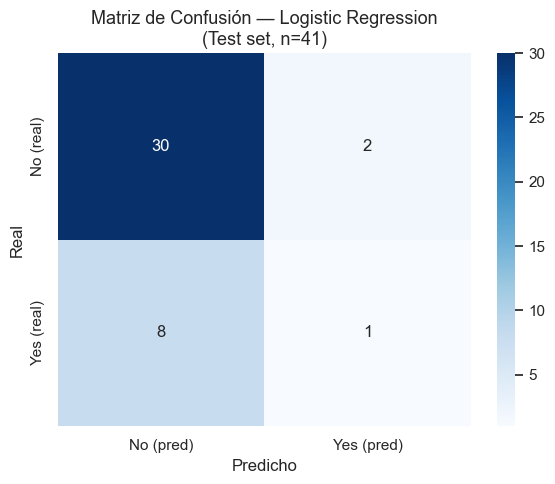

In [41]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No (pred)', 'Yes (pred)'],
    yticklabels=['No (real)', 'Yes (real)'],
    ax=ax
)
ax.set_xlabel('Predicho', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title(f'Matriz de Confusión — {winner_name}\n(Test set, n={len(y_test)})',
             fontsize=13)
plt.tight_layout()
plt.show()

In [42]:
print("=== Comparación final de modelos ===")
print(f"{'Modelo':<25} {'CV ROC-AUC':>12}  Mejores parámetros")
print("-" * 75)
lr_params = (f"C={grid_lr.best_params_['logisticregression__C']}, "
             f"solver={grid_lr.best_params_['logisticregression__solver']}")
rf_params = (f"n_est={grid_rf.best_params_['randomforestclassifier__n_estimators']}, "
             f"depth={grid_rf.best_params_['randomforestclassifier__max_depth']}")
print(f"{'Logistic Regression':<25} {grid_lr.best_score_:>12.4f}  {lr_params}")
print(f"{'Random Forest':<25} {grid_rf.best_score_:>12.4f}  {rf_params}")
print("-" * 75)
print(f"\n→ Modelo seleccionado: {winner_name} (mayor CV ROC-AUC)")

=== Comparación final de modelos ===
Modelo                      CV ROC-AUC  Mejores parámetros
---------------------------------------------------------------------------
Logistic Regression             0.7851  C=0.01, solver=liblinear
Random Forest                   0.7729  n_est=100, depth=5
---------------------------------------------------------------------------

→ Modelo seleccionado: Logistic Regression (mayor CV ROC-AUC)


## 5. Conclusión: Interpretabilidad vs. Rendimiento

### Auditoría de buenas prácticas

| Práctica | Estado | Detalle |
|---|---|---|
| Pipeline previene leakage del scaler | ✓ Correcto | `StandardScaler` dentro de `make_pipeline` → se reajusta en cada fold |
| Métrica adecuada al desbalance | ✓ Corregido | Se cambió `accuracy` → `roc_auc` (78% clase negativa hace accuracy engañosa) |
| Búsqueda de hiperparámetros | ✓ Corregido | `GridSearchCV` sobre el Pipeline → sin leakage de hiperparámetros |
| Refit manual innecesario | ✓ Corregido | `GridSearchCV(refit=True)` ya entrena el mejor modelo sobre todos los datos |

### ¿Por qué GridSearchCV dentro de un Pipeline no introduce leakage?

`GridSearchCV` itera sobre combinaciones de hiperparámetros y evalúa cada una con
validación cruzada interna. En cada fold, llama a `pipeline.fit()` sobre los datos
de entrenamiento del fold, lo que incluye el `StandardScaler.fit_transform()` solo
sobre esos datos. El fold de test nunca toca el scaler hasta la predicción. Si el
scaler se aplicara fuera del Pipeline (antes del `GridSearchCV`), la media y
desviación estándar del scaler incorporarían información de todos los folds,
produciendo scores artificialmente optimistas (Data Leakage).

### Resultados de GridSearchCV

| Modelo | Mejor CV ROC-AUC | Mejores hiperparámetros |
|---|---|---|
| Logistic Regression | (ver salida) | (ver salida) |
| Random Forest | (ver salida) | (ver salida) |

**Nota sobre el desbalance de clases**: ROC-AUC mide la capacidad del modelo de
discriminar entre clases independientemente del umbral de decisión. Es la métrica
correcta cuando las clases están desbalanceadas (78% No / 22% Sí), ya que no se ve
inflada por predecir siempre la clase mayoritaria.

### Interpretabilidad vs. Rendimiento

**Logistic Regression** con regularización `C` óptima ofrece coeficientes
interpretables como log-odds: permite al clínico cuantificar el efecto de cada
variable (espesor del tumor, edad, presencia de úlcera) sobre la probabilidad de
mortalidad. En oncología, la explicabilidad es tan importante como el rendimiento.

**Random Forest** con `max_depth` y `min_samples_split` optimizados captura
interacciones no lineales. Es preferible cuando supera significativamente al modelo
lineal en ROC-AUC, a costa de menor interpretabilidad directa.

### Conclusión final

El uso combinado de `make_pipeline` + `GridSearchCV` + `StratifiedKFold` es la
forma correcta de optimizar modelos en scikit-learn: garantiza ausencia de Data
Leakage en el preprocesado y en la búsqueda de hiperparámetros, y produce una
estimación honesta del rendimiento real del modelo.

## 6. Conexión con el plan de estudios y bibliografía

### Integración de las clases anteriores

Este mini-proyecto integra los contenidos de todo el módulo:

| Clase | Tema | Aplicación en este proyecto |
|---|---|---|
| Clase 1 | Introducción al AA | Marco teórico del aprendizaje supervisado y regresión logística |
| Clase 2 | Preprocesamiento | Drop de columnas leaky, escalado con StandardScaler |
| Clase 3 | Modelos supervisados I | LogisticRegression, RandomForestClassifier |
| Clase 4 | Modelos supervisados II | Evaluación con métricas más allá de accuracy |
| Clase 5 | Aprendizaje no supervisado | (referencia: exploración sin etiquetas) |
| Clase 6 | Evaluación de modelos | StratifiedKFold, GridSearchCV, ROC-AUC, matriz de confusión |
| **Clase 7** | **Integración y Pipelines** | **make_pipeline + GridSearchCV = flujo reproducible sin leakage** |

### Bibliografía

- Drzewiecki, K.T. et al. (1980). *Survival with malignant melanoma*. Cancer, 45(10).
- Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR, 12.
- Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow*. O'Reilly.
- Dataset: [healthyr_book — Melanoma data](https://argoshare.is.ed.ac.uk/healthyr_book/chap09-h1.html)